In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             classification_report, confusion_matrix)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# Load WoE-transformed data
train = pd.read_parquet('../data/processed/train_woe.parquet')
oot   = pd.read_parquet('../data/processed/oot_woe.parquet')

TARGET = 'TARGET'
features = [c for c in train.columns if c != TARGET]

X_train = train[features]
y_train = train[TARGET]
X_oot   = oot[features]
y_oot   = oot[TARGET]

print(f"Train: {X_train.shape}, default rate: {y_train.mean():.3f}")
print(f"OOT:   {X_oot.shape},   default rate: {y_oot.mean():.3f}")

Train: (246008, 55), default rate: 0.081
OOT:   (61503, 55),   default rate: 0.081


In [2]:
def ks_stat(y_true, y_prob):
    """KS statistic — max separation between TPR and FPR curves."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return round(max(tpr - fpr), 4)

def gini(y_true, y_prob):
    """Gini = 2*AUC - 1."""
    return round(2 * roc_auc_score(y_true, y_prob) - 1, 4)

def evaluate(name, model, X_tr, y_tr, X_ot, y_ot):
    """Full evaluation on train and OOT."""
    p_tr = model.predict_proba(X_tr)[:, 1]
    p_ot = model.predict_proba(X_ot)[:, 1]

    results = {
        'Model'     : name,
        'AUC Train' : round(roc_auc_score(y_tr, p_tr), 4),
        'AUC OOT'   : round(roc_auc_score(y_ot, p_ot), 4),
        'KS Train'  : ks_stat(y_tr, p_tr),
        'KS OOT'    : ks_stat(y_ot, p_ot),
        'Gini Train': gini(y_tr, p_tr),
        'Gini OOT'  : gini(y_ot, p_ot),
    }
    return results

In [3]:
# Stratified dummy — предсказывает случайно с учётом баланса классов
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)

dummy_res = evaluate('DummyClassifier', dummy, X_train, y_train, X_oot, y_oot)
print(dummy_res)

{'Model': 'DummyClassifier', 'AUC Train': np.float64(0.5), 'AUC OOT': np.float64(0.5016), 'KS Train': np.float64(0.0), 'KS OOT': np.float64(0.0032), 'Gini Train': np.float64(-0.0), 'Gini OOT': np.float64(0.0032)}


In [4]:
lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',  # handles imbalance
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
lr.fit(X_train, y_train)

lr_res = evaluate('Logistic Regression', lr, X_train, y_train, X_oot, y_oot)
print(lr_res)

{'Model': 'Logistic Regression', 'AUC Train': np.float64(0.7608), 'AUC OOT': np.float64(0.7608), 'KS Train': np.float64(0.393), 'KS OOT': np.float64(0.3946), 'Gini Train': np.float64(0.5217), 'Gini OOT': np.float64(0.5216)}


In [5]:
results_df = pd.DataFrame([dummy_res, lr_res])
results_df = results_df.set_index('Model')
print(results_df.to_string())

                     AUC Train  AUC OOT  KS Train  KS OOT  Gini Train  Gini OOT
Model                                                                          
DummyClassifier         0.5000   0.5016     0.000  0.0032     -0.0000    0.0032
Logistic Regression     0.7608   0.7608     0.393  0.3946      0.5217    0.5216


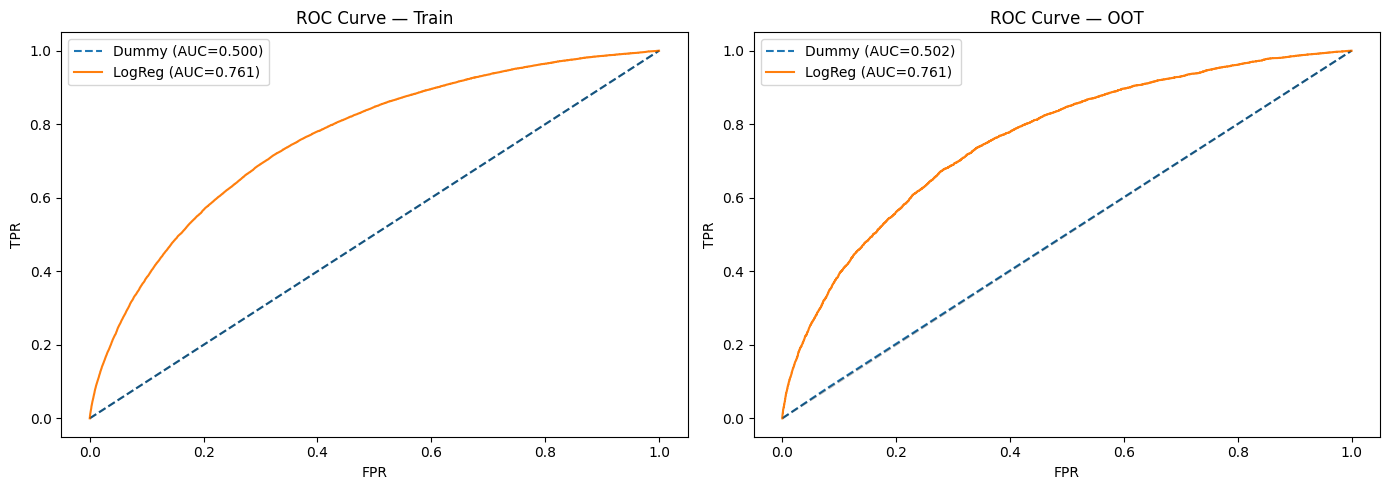

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (X, y, label) in zip(axes, [
    (X_train, y_train, 'Train'),
    (X_oot,   y_oot,   'OOT')
]):
    # Dummy
    fpr, tpr, _ = roc_curve(y, dummy.predict_proba(X)[:, 1])
    ax.plot(fpr, tpr, linestyle='--', label=f'Dummy (AUC={roc_auc_score(y, dummy.predict_proba(X)[:,1]):.3f})')

    # Logistic Regression
    fpr, tpr, _ = roc_curve(y, lr.predict_proba(X)[:, 1])
    ax.plot(fpr, tpr, label=f'LogReg (AUC={roc_auc_score(y, lr.predict_proba(X)[:,1]):.3f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'ROC Curve — {label}')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend()

plt.tight_layout()
plt.show()

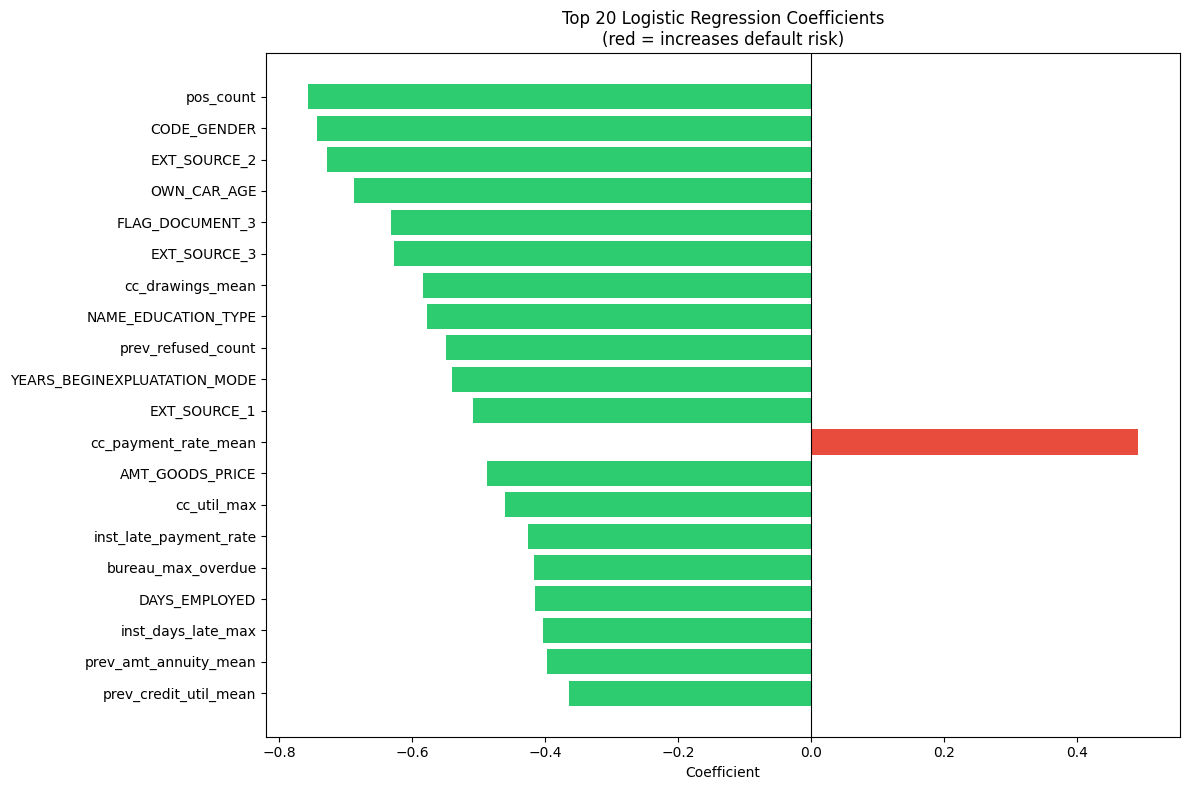

In [7]:
# Feature importance через коэффициенты LR
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr.coef_[0],
    'abs_coef': np.abs(lr.coef_[0])
}).sort_values('abs_coef', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df.head(20)['coefficient']]
plt.barh(coef_df.head(20)['feature'], coef_df.head(20)['coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 20 Logistic Regression Coefficients\n(red = increases default risk)')
plt.xlabel('Coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()